In [1]:
import os
import cv2
import argparse
import numpy as np
import time
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis, spearmanr, kendalltau, wasserstein_distance
from skimage.metrics import structural_similarity as ssim
from math import log2
import seaborn as sns
from ImageConstruct import CImageUtils,CImageAlpha,CImageMFS
from DatasetConstruct import CDatasetConstruct
from ImageSimilarity import CImageSimilarity
from ImageDecompose import CImageDecompose
np.set_printoptions(suppress=True, precision=8)

2026-05-31 01:56:17.070954: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-31 01:56:17.089101: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780192577.109834   99563 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780192577.115992   99563 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-31 01:56:17.139157: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
#不同的real/fake子图的相似度
def compaire_similar(real_list,fake_list):        
    all_data = []
    for real,fake in tqdm(zip(real_list,fake_list),total=len(real_list)):
        if np.sum(real) !=0 :
            metrics = CImageSimilarity(bins=256).compare(real, fake, auto_normalize=True)
            tmp = metrics['score']
            tmp["detail"] = metrics
            all_data.append(tmp)
    
    df_score = pd.DataFrame(all_data)
    df_score['top_n'] = df_score.index
    ys = ["Overall", "Histogram", "Statistical", "Information"]
    if len(real_list) > 1:
        CImageSimilarity.display_plots(df_score, x="top_n", ys=ys)
    else:
        display(df_score)
    return df_score
    
def show_compare(df_score,real_list,fake_list):
    #相似度score的拐点
    idx = CImageSimilarity.find_peaks(-df_score['Overall'],prominence=0.0001) 
    if len(idx) == 0:
        idx = int(np.argmin(df_score['Overall']))
        idx = [ idx ]
    print("key fade points:",idx)
    new_list = [real_list[i] for i in idx]
    CImageUtils.display(new_list)
    new_list = [fake_list[i] for i in idx]
    CImageUtils.display(new_list)

# 读取原始数据

In [3]:
real_mean = CImageUtils.read_image("./images/real-mean.exr")
real_std = CImageUtils.read_image("./images/real-std.exr")
real_mean = cv2.cvtColor(real_mean, cv2.COLOR_BGR2RGB)
real_std = cv2.cvtColor(real_std, cv2.COLOR_BGR2RGB)
fake_mean = CImageUtils.read_image("./images/fake-mean.exr")
fake_std = CImageUtils.read_image("./images/fake-std.exr")
fake_mean = cv2.cvtColor(fake_mean, cv2.COLOR_BGR2RGB)
fake_std = cv2.cvtColor(fake_std, cv2.COLOR_BGR2RGB)

real_mean = CImageUtils.resize(real_mean)
fake_mean = CImageUtils.resize(fake_mean)

real_mean_list = CImageDecompose(real_mean).get_svd_auto(count=128)
fake_mean_list = CImageDecompose(fake_mean).get_svd_auto(count=128)
real_std_list = CImageDecompose(real_std).get_svd_auto(count=128)
fake_std_list = CImageDecompose(fake_std).get_svd_auto(count=128)

# 选取合适的fade的参数

100%|██████████| 128/128 [06:28<00:00,  3.04s/it]


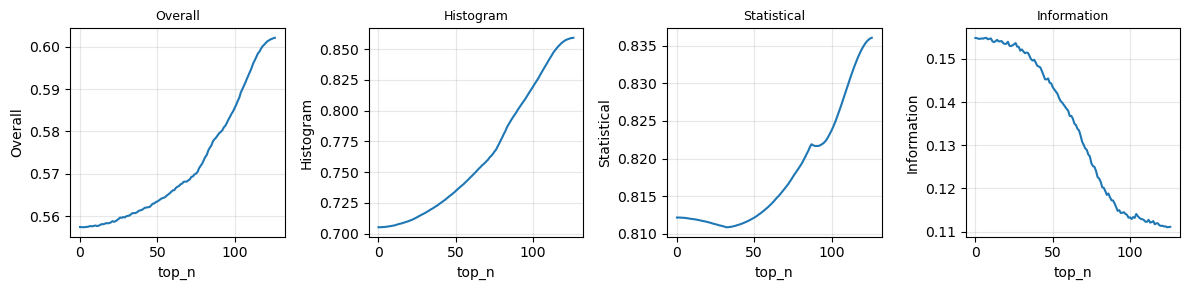

100%|██████████| 128/128 [07:02<00:00,  3.30s/it]


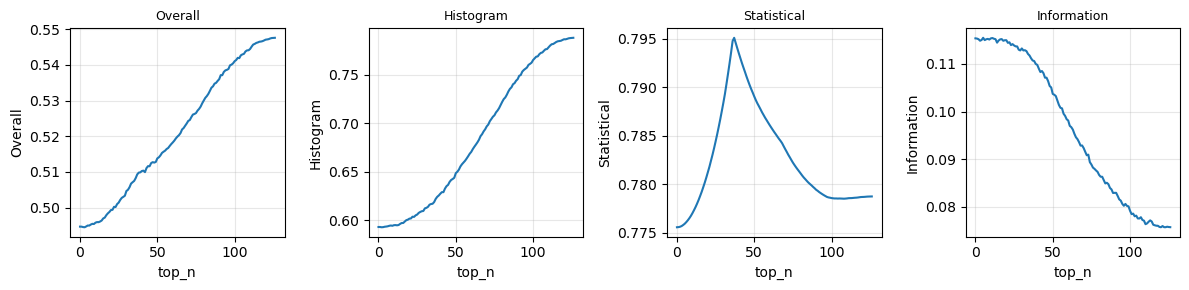

In [4]:
df_score = compaire_similar(real_mean_list,fake_mean_list)
df_score = compaire_similar(real_std_list,fake_std_list)

In [5]:
show_compare(df_score,real_svd_mean,fake_svd_mean)

NameError: name 'real_svd_mean' is not defined

# Local alpha

In [ ]:
real_alpha = CImageAlpha(real_mean).get_raw_alpha()
fake_alpha = CImageAlpha(fake_mean).get_raw_alpha()
real_alpha_list = CImageDecompose(real_alpha).get_svd_auto(count=128)
fake_alpha_list = CImageDecompose(fake_alpha).get_svd_auto(count=128)
df_score = compaire_similar(real_alpha_list,fake_alpha_list)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_alpha = CImageAlpha(real_std).get_raw_alpha()
fake_alpha = CImageAlpha(fake_std).get_raw_alpha()
real_alpha_list = CImageDecompose(real_alpha).get_svd_auto(count=128)
fake_alpha_list = CImageDecompose(fake_alpha).get_svd_auto(count=128)
df_score = compaire_similar(real_alpha_list,fake_alpha_list)
show_compare(df_score,real_alpha_list,fake_alpha_list)

In [ ]:
real_list = []
fake_list = []
for real,fake in tqdm(zip(real_mean_list,fake_mean_list),total=len(real_mean_list)):
    img1 = CImageAlpha(real).get_raw_alpha()
    img2 = CImageAlpha(fake).get_raw_alpha()
    real_list.append(img1)
    fake_list.append(img2)

df_score = compaire_similar(real_list,fake_list)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_list = []
fake_list = []
for real,fake in tqdm(zip(real_std_list,fake_std_list),total=len(real_std_list)):
    img1 = CImageAlpha(real).get_raw_alpha()
    img2 = CImageAlpha(fake).get_raw_alpha()
    real_list.append(img1)
    fake_list.append(img2)

df_score = compaire_similar(real_list,fake_list)
df_score = compaire_similar(real_std_list,fake_std_list)
show_compare(df_score,real_list,fake_list)
#show_compare(df_score,real_list,fake_list)
#CImageUtils.display([real_alpha_mean,real_alpha_std])
#CImageUtils.display([fake_alpha_mean,fake_alpha_std])

# Gray & Bin & alpha

In [ ]:
real_gray = CImageAlpha(real_mean_list[51]).get_gray_alpha(count=128)
fake_gray = CImageAlpha(fake_mean_list[51]).get_gray_alpha(count=128)
df_score = compaire_similar(real_gray,fake_gray)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_gray = CImageAlpha(real_std_list[51]).get_gray_alpha(count=128)
fake_gray = CImageAlpha(fake_std_list[51]).get_gray_alpha(count=128)
df_score = compaire_similar(real_gray,fake_gray)
df_score = compaire_similar(real_std_list,fake_std_list)

In [ ]:
real_bin = CImageAlpha(real_mean_list[51]).get_bin_alpha(count=128)
fake_bin = CImageAlpha(fake_mean_list[51]).get_bin_alpha(count=128)
df_score = compaire_similar(real_bin,fake_bin)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_bin = CImageAlpha(real_std_list[51]).get_bin_alpha(count=128)
fake_bin = CImageAlpha(fake_std_list[51]).get_bin_alpha(count=128)
df_score = compaire_similar(real_bin,fake_bin)
df_score = compaire_similar(real_std_list,fake_std_list)

In [ ]:
real_alpha = CImageAlpha(real_mean_list[51]).get_svd_alpha(count=128)
fake_alpha = CImageAlpha(fake_mean_list[51]).get_svd_alpha(count=128)
df_score = compaire_similar(real_alpha,fake_alpha)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_alpha = CImageAlpha(real_std_list[51]).get_svd_alpha(count=128)
fake_alpha = CImageAlpha(fake_std_list[51]).get_svd_alpha(count=128)
df_score = compaire_similar(real_alpha,fake_alpha)
df_score = compaire_similar(real_std_list,fake_std_list)

# MFS
1. R,G,B
2. A,D,F

In [ ]:
real_mfs_img = CImageMFS(real_mean_list[51],count = 128).get_image_mfs()
fake_mfs_img = CImageMFS(fake_mean_list[51],count = 128).get_image_mfs()

real_mfs_img_list = CImageDecompose(real_mfs_img[0]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[0]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[1]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[1]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[2]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[2]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
compaire_similar(real_mean_list,fake_mean_list)

In [ ]:
real_mfs_img = CImageMFS(real_std_list[51],count = 128).get_image_mfs()
fake_mfs_img = CImageMFS(fake_std_list[51],count = 128).get_image_mfs()

real_mfs_img_list = CImageDecompose(real_mfs_img[0]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[0]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[1]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[1]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[2]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[2]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
compaire_similar(real_std_list,fake_std_list)

In [ ]:
real_mfs_img = CImageMFS(real_mean_list[51],count = 128).get_mfs_image()
fake_mfs_img = CImageMFS(fake_mean_list[51],count = 128).get_mfs_image()
real_mfs_img_list = CImageDecompose(real_mfs_img[0]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[0]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[1]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[1]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[2]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[2]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
compaire_similar(real_mean_list,fake_mean_list)

In [ ]:
real_mfs_img = CImageMFS(real_std_list[51],count = 128).get_mfs_image()
fake_mfs_img = CImageMFS(fake_std_list[51],count = 128).get_mfs_image()
real_mfs_img_list = CImageDecompose(real_mfs_img[0]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[0]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[1]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[1]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[2]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[2]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
compaire_similar(real_std_list,fake_std_list)